In [16]:
import batsim
import galsim
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['cmr10']
plt.rcParams['mathtext.fontset'] ='cm'
plt.rcParams['figure.facecolor'] = 'white'
plt.rc('axes', unicode_minus=False)
plt.rc('axes.formatter', use_mathtext=True)

In this example notebook, we cover calling the BATSim renderer without providing a transform. 

Given BATSim's function as a non-affine shear renderer, this example is not representative of real usage, but is intended to provide an overview of how to use the renderer and some of the less advanced configuration options that are available through it.

BATSim is intended to operate as an extension to Galsim, and as such, its renderer is designed to operate on Galsim objects. We recomend familiarising yourself with Galsim's API if necessary, as our examples assume existing experience running Galsim.

https://galsim-developers.github.io/GalSim/_build/html/index.html

## The Simplest Render

First, let's directly compare drawing a galaxy with BATSim to Galsim. We define our galaxy object, image size, and pixel scale.

The workhorse function of BATSim is ``batsim.simulate_galaxy()`` this function applies coordinate transforms, determines the necessary internal rendering resolution (which is typically 4x-64x higher than the requested resolution), samples the galaxy profile, applys any convolutions, and returns us the final image at the requested size and pixel scale in the form of a numpy array.

Currently, BATSim only supports square images.

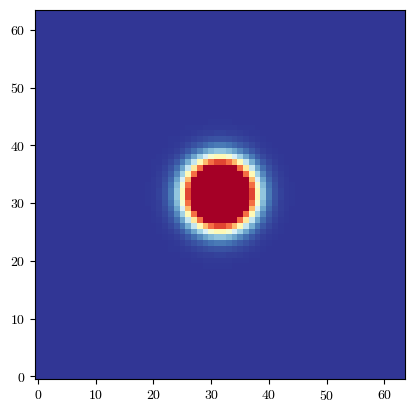

In [17]:
# Define our galaxy profile as a GSObject
gal = galsim.Sersic(half_light_radius=0.1, n=2)

# Define image parameters
ngrid = 64 # number of pixels along x and y. Total pixels is n_grid*n_grid
pix_scale = 0.2 # number of arcseconds each pixels should cover

# Call BATSim's renderer, returns np.array
gal_image = batsim.simulate_galaxy(
    gal_obj=gal, # pass the GSObject profile
    ngrid=ngrid, # If None, BATSim chooses a sensible size based on scale
    scale=pix_scale # pixel scale of the FINAL output image
)

# Call BATSim's plotting utility to get a nicely normalised image
fig = batsim.pltutil.make_plot_image(gal_image)

If desired, and as would typically be the case, a PSF can also be provided which will be convolved with the image

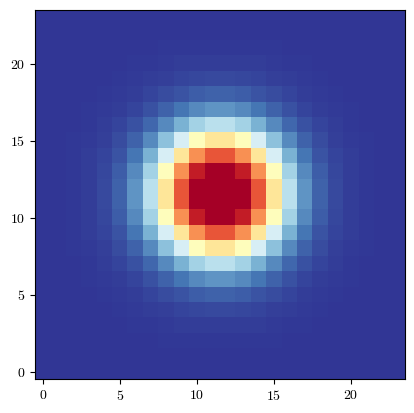

In [18]:
# Define PSF
psf = galsim.Moffat(beta=3.5, fwhm=0.7)

# Call renderer passing PSF as well
gal_with_psf_image = batsim.simulate_galaxy(
    gal_obj=gal,
    psf_obj=psf,
    ngrid=None, # This time lets omit it to see what BATSim chooses
    scale=pix_scale
)

# Call BATSim's plotting utility to get a nicely normalised image
fig = batsim.pltutil.make_plot_image(gal_with_psf_image)

By default the BATSim renderer applies a pixel response function to the image. This is an additional top-hat smoothing kernel that accounts for the fact real detectors are composed of finite pixels with hard edges. If you wish to simulate images representative of an atypical detector with non-square pixels or a different response function, you can disable this through the ``draw_method`` argument.

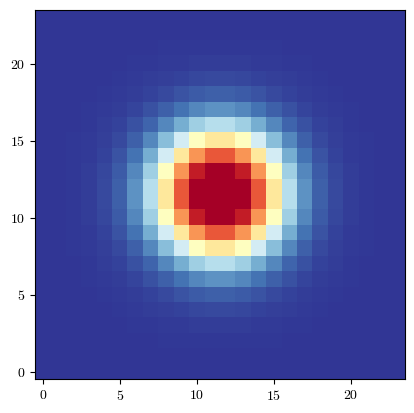

In [19]:
# Define PSF
psf = galsim.Moffat(beta=3.5, fwhm=0.7)

# Call renderer passing PSF as well
gal_with_psf_image = batsim.simulate_galaxy(
    gal_obj=gal,
    psf_obj=psf,
    ngrid=None, # This time lets omit it to see what BATSim chooses
    scale=pix_scale,
    draw_method="no_pixel" # alternative is "auto", which applies pixel response
)

# Call BATSim's plotting utility to get a nicely normalised image
fig = batsim.pltutil.make_plot_image(gal_with_psf_image)

It is important to note that, due to the nature of non-affine shear, BATSim's renderer is significantly slower than Galsim's. As such, for work like this where no transform is required, we recomend simply sticking to Galsim's own drawing methods.